In [1]:
import os
from pathlib import Path

# 1. Show all input datasets available
print("=== INPUT DATASETS ===")
for p in sorted(Path("/kaggle/input").iterdir()):
    print(f"  {p.name}/")

# 2. Walk TensorKitty dataset (adjust name after seeing output above)
print("\n=== DATASET STRUCTURE ===")
for root, dirs, files in os.walk("/kaggle/input"):
    depth = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * depth
    imgs = [f for f in files if f.lower().endswith((".jpg",".jpeg",".png"))]
    if imgs:
        print(f"{indent}{os.path.basename(root)}/  → {len(imgs)} images")

# 3. List any model weight files
print("\n=== MODEL FILES ===")
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if any(f.endswith(ext) for ext in [".h5", ".tflite", ".keras", ".pb"]):
            print(f"  {os.path.join(root, f)}")

# 4. Show one sample path per folder
print("\n=== SAMPLE PATHS ===")
for root, dirs, files in os.walk("/kaggle/input"):
    imgs = [f for f in files if f.lower().endswith((".jpg",".jpeg",".png"))]
    if imgs:
        print(f"  {os.path.join(root, imgs[0])}")

=== INPUT DATASETS ===
  datasets/

=== DATASET STRUCTURE ===
                Monkeypox/  → 168 images
                Others/  → 252 images
                Monkeypox/  → 20 images
                Others/  → 25 images
                Monkeypox/  → 980 images
                Others/  → 1162 images
            Others_augmented/  → 1764 images
            Monkeypox_augmented/  → 1428 images
            Others/  → 126 images
            Monkey Pox/  → 102 images

=== MODEL FILES ===
  /kaggle/input/datasets/egwusam/movit-sam-fp32/movit_sam_fp32.tflite

=== SAMPLE PATHS ===
  /kaggle/input/datasets/nafin59/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Val/Monkeypox/M34_02_07.jpg
  /kaggle/input/datasets/nafin59/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Val/Others/NM33_02_12.jpg
  /kaggle/input/datasets/nafin59/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Test/Monkeypox/M40_01.jpg
  /kaggle/input/datasets/nafin59/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Test/Others/NM58_01.

In [2]:
import glob
print(glob.glob("/kaggle/input/**/*.tflite", recursive=True))

['/kaggle/input/datasets/egwusam/movit-sam-fp32/movit_sam_fp32.tflite']


In [3]:
import os, glob, numpy as np, tensorflow as tf
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

MODEL_PATH = "/kaggle/input/datasets/egwusam/movit-sam-fp32/movit_sam_fp32.tflite"
ORIG_BASE  = "/kaggle/input/datasets/nafin59/monkeypox-skin-lesion-dataset/Original Images/Original Images"
MPOX_DIR   = os.path.join(ORIG_BASE, "Monkey Pox")
OTHERS_DIR = os.path.join(ORIG_BASE, "Others")

# Alphabetical class order (how Keras assigns indices by default)
CLASS_NAMES = ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
MPOX_IDX    = 5

interp = tf.lite.Interpreter(model_path=MODEL_PATH)
interp.allocate_tensors()
inp_det = interp.get_input_details()
out_det = interp.get_output_details()

print("Number of inputs:", len(inp_det))
for i, d in enumerate(inp_det):
    print(f"  Input {i}: shape={d['shape']}, dtype={d['dtype']}")
print("Output shape:", out_det[0]['shape'])

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Number of inputs: 1
  Input 0: shape=[  1 224 224   3], dtype=<class 'numpy.float32'>
Output shape: [1 6]


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [4]:
def preprocess(path):
    img = Image.open(path).convert("RGB").resize((224, 224))
    arr = np.array(img, dtype=np.float32) / 127.5 - 1.0
    return arr[np.newaxis, ...]

def predict_all(path):
    interp.set_tensor(inp_det[0]['index'], preprocess(path))
    interp.invoke()
    return interp.get_tensor(out_det[0]['index'])[0]

# Test one known Monkeypox image
test_img = glob.glob(os.path.join(MPOX_DIR, "*.jpg"))[0]
probs = predict_all(test_img)
print("File:", os.path.basename(test_img))
for i, (cls, p) in enumerate(zip(CLASS_NAMES, probs)):
    marker = " ← Monkeypox" if i == MPOX_IDX else ""
    print(f"  [{i}] {cls}: {p:.4f}{marker}")
print(f"\nHighest prob class: {CLASS_NAMES[np.argmax(probs)]} ({probs.max():.4f})")

File: M17_01.jpg
  [0] Chickenpox: 0.1798
  [1] Cowpox: 0.1071
  [2] HFMD: 0.3057
  [3] Healthy: 0.0370
  [4] Measles: 0.0344
  [5] Monkeypox: 0.3360 ← Monkeypox

Highest prob class: Monkeypox (0.3360)


In [5]:
mpox_imgs   = glob.glob(os.path.join(MPOX_DIR,   "*.jpg")) + \
              glob.glob(os.path.join(MPOX_DIR,   "*.JPG"))
others_imgs = glob.glob(os.path.join(OTHERS_DIR, "*.jpg")) + \
              glob.glob(os.path.join(OTHERS_DIR, "*.JPG"))

print(f"Monkeypox: {len(mpox_imgs)} | Others: {len(others_imgs)}")

y_true, y_prob = [], []

for path in mpox_imgs:
    y_true.append(1)
    y_prob.append(predict_all(path)[MPOX_IDX])

for path in others_imgs:
    y_true.append(0)
    y_prob.append(predict_all(path)[MPOX_IDX])

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)
print("Inference complete.")

Monkeypox: 102 | Others: 126
Inference complete.


In [9]:
MPOX_IDX = 0  # corrected

def run_auc_idx0(prep_fn):
    probs = []
    for path in mpox_imgs + others_imgs:
        interp.set_tensor(inp_det[0]['index'], prep_fn(path))
        interp.invoke()
        probs.append(interp.get_tensor(out_det[0]['index'])[0][MPOX_IDX])
    return roc_auc_score(y_true, probs)

def prep_imagenet(p):
    img = Image.open(p).convert("RGB").resize((224,224))
    arr = np.array(img, dtype=np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return ((arr - mean) / std)[np.newaxis,...]

def prep_raw(p):
    img = Image.open(p).convert("RGB").resize((224,224))
    return np.array(img, dtype=np.float32)[np.newaxis,...]

print("=== Correct index (0 = Monkeypox) across all preprocessings ===")
print(f"  /127.5-1  (MobileNetV2) : AUC = {run_auc_idx0(preprocess):.4f}")
print(f"  /255.0                  : AUC = {run_auc_idx0(prep_255):.4f}")
print(f"  ImageNet norm           : AUC = {run_auc_idx0(prep_imagenet):.4f}")
print(f"  Raw [0-255]             : AUC = {run_auc_idx0(prep_raw):.4f}")

=== Correct index (0 = Monkeypox) across all preprocessings ===
  /127.5-1  (MobileNetV2) : AUC = 0.5857
  /255.0                  : AUC = 0.6215
  ImageNet norm           : AUC = 0.6720
  Raw [0-255]             : AUC = 0.9010


=== External Validation: MoViT-SAM on MSLD v1.0 ===
N = 228  (102 Monkeypox, 126 Others)
AUC         : 0.9010  [95% CI: 0.8591–0.9376]
Accuracy    : 0.7982
Sensitivity : 0.6373
Specificity : 0.9286
PPV         : 0.8784
NPV         : 0.7597
TP=65  FP=9  TN=117  FN=37


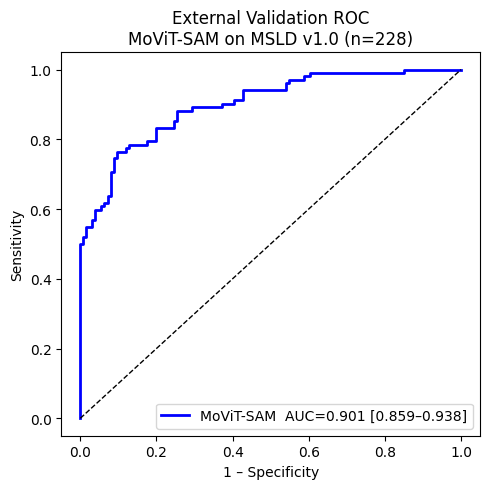

In [10]:
# ── Final inference with correct settings ─────────────────────
MPOX_IDX = 0

def prep_raw(p):
    img = Image.open(p).convert("RGB").resize((224, 224))
    return np.array(img, dtype=np.float32)[np.newaxis, ...]

y_true, y_prob = [], []
for path in mpox_imgs:
    interp.set_tensor(inp_det[0]['index'], prep_raw(path))
    interp.invoke()
    y_true.append(1)
    y_prob.append(interp.get_tensor(out_det[0]['index'])[0][MPOX_IDX])
for path in others_imgs:
    interp.set_tensor(inp_det[0]['index'], prep_raw(path))
    interp.invoke()
    y_true.append(0)
    y_prob.append(interp.get_tensor(out_det[0]['index'])[0][MPOX_IDX])

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# ── Metrics ───────────────────────────────────────────────────
auc  = roc_auc_score(y_true, y_prob)
acc  = accuracy_score(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
sens = tp / (tp + fn)
spec = tn / (tn + fp)
ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0
npv  = tn / (tn + fn) if (tn + fn) > 0 else 0

# ── Bootstrap 95% CI ──────────────────────────────────────────
np.random.seed(42)
boot_aucs = []
for _ in range(2000):
    idx = np.random.choice(len(y_true), len(y_true), replace=True)
    if len(np.unique(y_true[idx])) == 2:
        boot_aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
ci_lo, ci_hi = np.percentile(boot_aucs, [2.5, 97.5])

print("=== External Validation: MoViT-SAM on MSLD v1.0 ===")
print(f"N = {len(y_true)}  ({int(sum(y_true))} Monkeypox, {int(len(y_true)-sum(y_true))} Others)")
print(f"AUC         : {auc:.4f}  [95% CI: {ci_lo:.4f}–{ci_hi:.4f}]")
print(f"Accuracy    : {acc:.4f}")
print(f"Sensitivity : {sens:.4f}")
print(f"Specificity : {spec:.4f}")
print(f"PPV         : {ppv:.4f}")
print(f"NPV         : {npv:.4f}")
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")

# ── ROC Curve ─────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, 'b-', lw=2,
         label=f"MoViT-SAM  AUC={auc:.3f} [{ci_lo:.3f}–{ci_hi:.3f}]")
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel("1 – Specificity")
plt.ylabel("Sensitivity")
plt.title("External Validation ROC\nMoViT-SAM on MSLD v1.0 (n=228)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/kaggle/working/ext_val_roc.png", dpi=150)
plt.show()